In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [16]:
FIGURES_DIR = Path("reports/figures")

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [17]:
df = pd.read_csv(
    "saudi_data_jobs_cleaned.csv"
)

df.head()

,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes,city_cleaned,experience_category,role_category
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...,Jeddah,Entry Level,Data Analysis
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...,Mahd Adh Dhahab,Entry Level,Data Science
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...,Riyadh,Entry Level,Data Analysis
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...,Not specified,Entry Level,Business / Financial Analytics
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...,Jeddah,Not Specified,BI


In [18]:
df.columns.tolist()

['job_id',
 'job_title',
 'company',
 'city',
 'role_type',
 'experience_level',
 'skills',
 'tools',
 'source',
 'job_link',
 'date_collected',
 'notes',
 'city_cleaned',
 'experience_category',
 'role_category']

In [19]:
job_notes_df = df[
    [
        "job_id",
        "notes"
    ]
].copy()


job_notes_df.head()

,job_id,notes
0,1,Customer experience data analyst role in autom...
1,2,Mining sector data science role. Focuses on ge...
2,3,Entry-level data analyst role for Madinaty Sup...
3,4,Entry-level pricing analytics role. Focuses on...
4,5,Mid-level Power BI Developer role in Jeddah. F...


In [20]:
job_notes_df["notes"] = (
    job_notes_df["notes"]
    .fillna("")
)

In [21]:
job_notes_df["notes"] = (
    job_notes_df["notes"]
    .str.lower()
)

In [22]:
focus_keywords = [

    "analysis",
    "analytics",
    "dashboard",
    "reporting",
    "business intelligence",
    "power bi",
    "data visualization",
    "machine learning",
    "python",
    "sql",
    "automation",
    "forecasting",
    "data quality",
    "data governance",
    "customer",
    "finance",
    "operations",
    "mining"

]

In [23]:
keyword_counts = {}

for keyword in focus_keywords:

    count = (
        job_notes_df["notes"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
        .sum()
    )

    keyword_counts[keyword] = count


keyword_counts

{'analysis': np.int64(21),
 'analytics': np.int64(19),
 'dashboard': np.int64(24),
 'reporting': np.int64(16),
 'business intelligence': np.int64(2),
 'power bi': np.int64(11),
 'data visualization': np.int64(0),
 'machine learning': np.int64(5),
 'python': np.int64(15),
 'sql': np.int64(22),
 'automation': np.int64(8),
 'forecasting': np.int64(6),
 'data quality': np.int64(13),
 'data governance': np.int64(6),
 'customer': np.int64(3),
 'finance': np.int64(0),
 'operations': np.int64(3),
 'mining': np.int64(3)}

In [24]:
focus_analysis = pd.DataFrame(
    keyword_counts.items(),
    columns=[
        "Focus_Area",
        "Number_of_jobs"
    ]
)


focus_analysis = focus_analysis.sort_values(
    "Number_of_jobs",
    ascending=False
)


focus_analysis

,Focus_Area,Number_of_jobs
2,dashboard,24
9,sql,22
0,analysis,21
1,analytics,19
3,reporting,16
8,python,15
12,data quality,13
5,power bi,11
10,automation,8
11,forecasting,6


In [25]:
top_focus = focus_analysis.head(10)

top_focus

,Focus_Area,Number_of_jobs
2,dashboard,24
9,sql,22
0,analysis,21
1,analytics,19
3,reporting,16
8,python,15
12,data quality,13
5,power bi,11
10,automation,8
11,forecasting,6


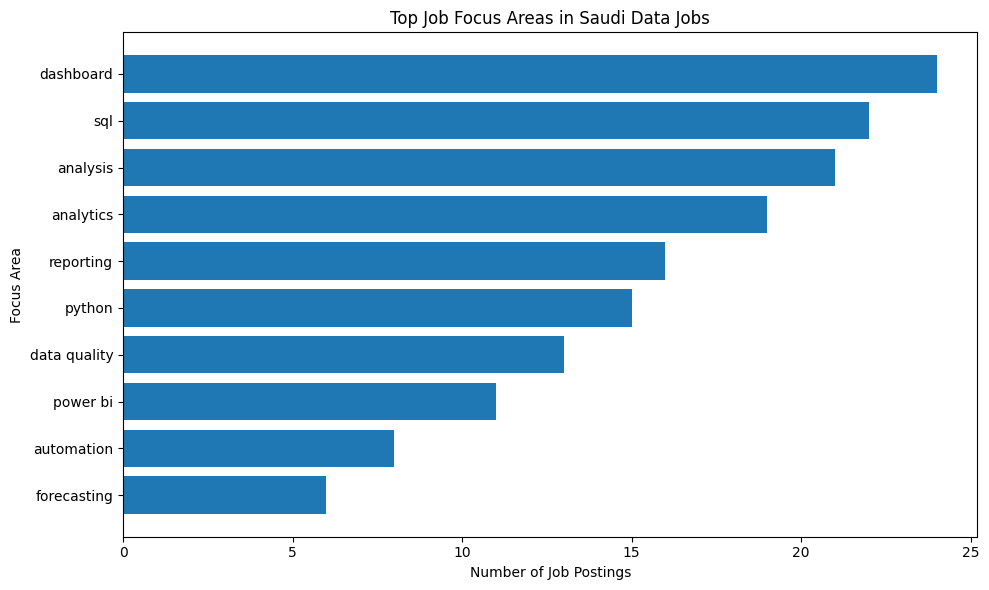

In [26]:
plt.figure(figsize=(10,6))


plt.barh(
    top_focus["Focus_Area"],
    top_focus["Number_of_jobs"]
)


plt.xlabel(
    "Number of Job Postings"
)


plt.ylabel(
    "Focus Area"
)


plt.title(
    "Top Job Focus Areas in Saudi Data Jobs"
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "top_job_focus_areas.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [27]:
role_focus_df = job_notes_df.merge(
    df[
        [
            "job_id",
            "role_category"
        ]
    ],
    on="job_id",
    how="left"
)


role_focus_df.head()

,job_id,notes,role_category
0,1,customer experience data analyst role in autom...,Data Analysis
1,2,mining sector data science role. focuses on ge...,Data Science
2,3,entry-level data analyst role for madinaty sup...,Data Analysis
3,4,entry-level pricing analytics role. focuses on...,Business / Financial Analytics
4,5,mid-level power bi developer role in jeddah. f...,BI


In [28]:
def extract_focus(text):

    found = []

    for keyword in focus_keywords:

        if keyword in text:
            found.append(keyword)

    return found

In [30]:
role_focus_df["focus_area"] = (
    role_focus_df["notes"]
    .apply(extract_focus)
)


role_focus_df.head()

,job_id,notes,role_category,focus_area
0,1,customer experience data analyst role in autom...,Data Analysis,"[dashboard, customer]"
1,2,mining sector data science role. focuses on ge...,Data Science,"[analytics, dashboard, python, sql, automation..."
2,3,entry-level data analyst role for madinaty sup...,Data Analysis,"[analytics, dashboard, python, sql, data quality]"
3,4,entry-level pricing analytics role. focuses on...,Business / Financial Analytics,"[analytics, dashboard, customer]"
4,5,mid-level power bi developer role in jeddah. f...,BI,"[dashboard, reporting, power bi, python, sql, ..."


In [31]:
role_focus_df = role_focus_df.explode(
    "focus_area"
)


role_focus_df.head()

,job_id,notes,role_category,focus_area
0,1,customer experience data analyst role in autom...,Data Analysis,dashboard
0,1,customer experience data analyst role in autom...,Data Analysis,customer
1,2,mining sector data science role. focuses on ge...,Data Science,analytics
1,2,mining sector data science role. focuses on ge...,Data Science,dashboard
1,2,mining sector data science role. focuses on ge...,Data Science,python


In [32]:
focus_by_role = pd.crosstab(

    role_focus_df["focus_area"],

    role_focus_df["role_category"]

)


focus_by_role

role_category,AI,BI,Business / Financial Analytics,Data Analysis,Data Science,Fraud Analytics,Governance,Marketing Analytics,Other,Performance Analytics,Product Analytics,Research Analytics
focus_area,,,,,,,,,,,,
analysis,4,2,1,2,2,3,1,0,0,3,1,2
analytics,2,2,2,1,2,2,0,1,1,3,1,2
automation,1,3,0,0,2,0,0,0,0,2,0,0
business intelligence,0,2,0,0,0,0,0,0,0,0,0,0
customer,0,0,1,1,1,0,0,0,0,0,0,0
dashboard,2,6,3,4,2,1,1,1,0,4,0,0
data governance,1,1,0,1,0,0,2,0,1,0,0,0
data quality,2,3,0,1,2,0,4,0,0,1,0,0
forecasting,1,1,1,1,0,0,0,0,0,1,0,1


In [33]:
import seaborn as sns

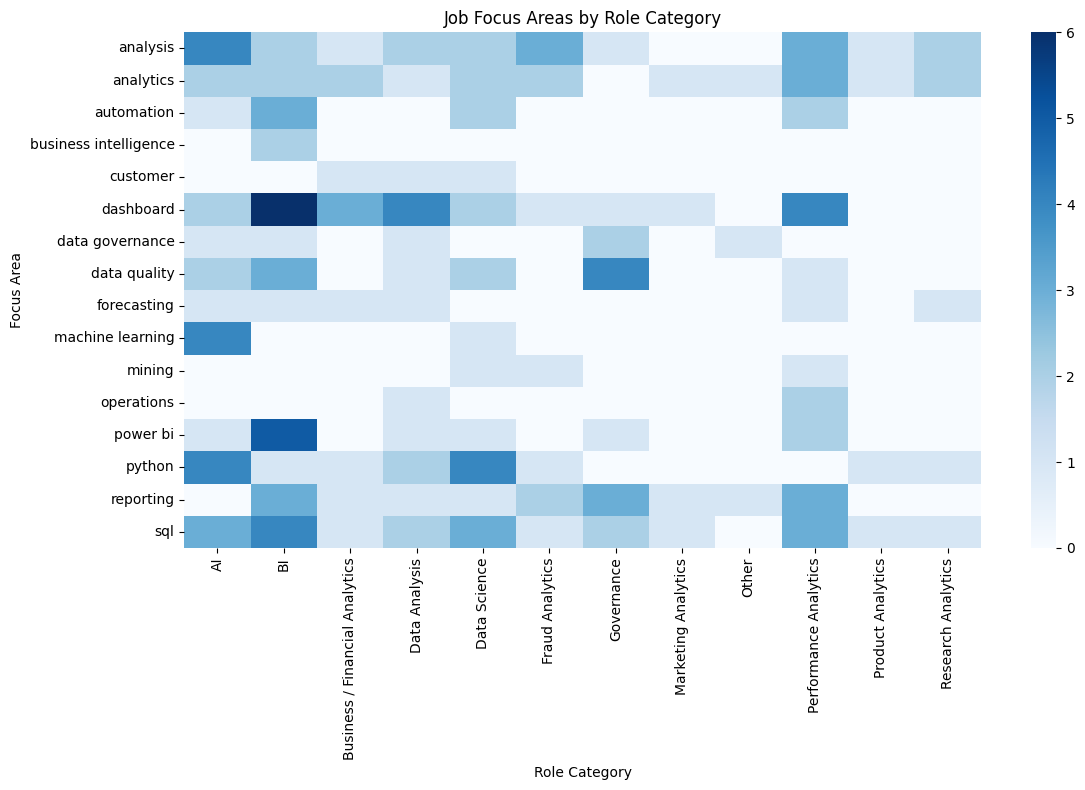

In [34]:
plt.figure(figsize=(12,8))


sns.heatmap(
    focus_by_role,
    cmap="Blues"
)


plt.title(
    "Job Focus Areas by Role Category"
)


plt.xlabel(
    "Role Category"
)


plt.ylabel(
    "Focus Area"
)


plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "focus_by_role_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Day 24 - Job Focus Analysis

This notebook analyzes job descriptions from Saudi data-related roles to identify the most common focus areas mentioned in job postings.

The analysis is based on the cleaned Saudi Data Jobs dataset containing 45 job postings.